# Code for Final Report 

---

### Import & Load Data

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [150]:
df = pd.read_csv("Student_Dropout_20260222.csv", low_memory=False)

# Clean column names
df.columns = df.columns.str.strip()

print(df.shape)
print(df.columns.tolist())
df.head()

(91865, 15)
['School Year', 'District Code', 'District', 'School Code', 'Organization', 'Race', 'Gender', 'Grade', 'SpecialDemo', 'Geography', 'SubGroup', 'RowStatus', 'Dropouts', 'Students', 'PctDropouts']


,School Year,District Code,District,School Code,Organization,Race,Gender,Grade,SpecialDemo,Geography,SubGroup,RowStatus,Dropouts,Students,PctDropouts
0,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,9th Grade,All Students,All Students,Hispanic/Latino/9th Grade,REPORTED,67,"2,051",3.3
1,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,10th Grade,All Students,All Students,Hispanic/Latino/10th Grade,REPORTED,44,"1,847",2.4
2,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,11th Grade,All Students,All Students,Hispanic/Latino/11th Grade,REPORTED,27,"1,568",1.7
3,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,12th Grade,All Students,All Students,Hispanic/Latino/12th Grade,REPORTED,14,"1,366",1.0
4,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,All Students,All Students,All Students,Hispanic/Latino,REPORTED,152,"6,832",2.2


### Initial Cleaning 

In [151]:
# Keep only reported rows
df = df[df["RowStatus"] == "REPORTED"].copy()

# Convert numeric columns
df["Students"] = pd.to_numeric(
    df["Students"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

df["Dropouts"] = pd.to_numeric(
    df["Dropouts"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

df["PctDropouts"] = pd.to_numeric(
    df["PctDropouts"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

# Remove very small groups so percentages are more stable
# You can change 30 to 20 if too much data gets removed
df = df[df["Students"] >= 30].copy()

print(df.shape)
df.head()

(19831, 15)


,School Year,District Code,District,School Code,Organization,Race,Gender,Grade,SpecialDemo,Geography,SubGroup,RowStatus,Dropouts,Students,PctDropouts
0,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,9th Grade,All Students,All Students,Hispanic/Latino/9th Grade,REPORTED,67,2051,3.3
1,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,10th Grade,All Students,All Students,Hispanic/Latino/10th Grade,REPORTED,44,1847,2.4
2,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,11th Grade,All Students,All Students,Hispanic/Latino/11th Grade,REPORTED,27,1568,1.7
3,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,12th Grade,All Students,All Students,Hispanic/Latino/12th Grade,REPORTED,14,1366,1.0
4,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,All Students,All Students,All Students,Hispanic/Latino,REPORTED,152,6832,2.2


### Feature Engineering 

In [152]:
df["Race_Gender"] = df["Race"].astype(str) + "_" + df["Gender"].astype(str)
df["Grade_SpecialDemo"] = df["Grade"].astype(str) + "_" + df["SpecialDemo"].astype(str)
df["District_Geography"] = df["District"].astype(str) + "_" + df["Geography"].astype(str)

### Remove Leakage/Drop Unneccesary Columns

In [153]:
df_model = df.drop(columns=[
    "Dropouts",
    "Students",
    "District Code",
    "School Code",
    "SubGroup",
    "RowStatus"
], errors="ignore").copy()

print(df_model.columns.tolist())

['School Year', 'District', 'Organization', 'Race', 'Gender', 'Grade', 'SpecialDemo', 'Geography', 'PctDropouts', 'Race_Gender', 'Grade_SpecialDemo', 'District_Geography']


### Define Regression Target and Features

In [154]:
y = df_model["PctDropouts"]
X = df_model.drop(columns=["PctDropouts"])

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['District', 'Organization', 'Race', 'Gender', 'Grade', 'SpecialDemo', 'Geography', 'Race_Gender', 'Grade_SpecialDemo', 'District_Geography']
Numerical columns: ['School Year']


### Train Test Split

In [155]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Pre-processing 

In [156]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numerical_cols)
])

### Baseline Predictions (code only)

In [157]:
# This predicts the mean dropout rate for every subgroup.
# It is not one of the 4 main models, but helps show whether
# machine learning adds value.

baseline_pred = np.full(len(y_test), y_train.mean())

## Regression Models

**Why these models?**
- Linear Regression: tests whether dropout patterns are mostly simple and linear.
- Decision Tree (2A): tests whether simple rule-based subgroup splits work.
- Decision Tree (2B): tests whether deeper subgroup rules improve prediction.
- Random Forest: tests whether combining many trees captures interactions better.
- Neural Network: tests whether highly complex nonlinear patterns exist.
- Gradient Boosting: tests whether sequentially correcting errors improves prediction.

### Model 1: Linear Regression (code only)

In [158]:
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

### Model 2A: Decision Tree (single tree) (code only)

In [159]:
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(max_depth=10, random_state=42))
])

### Model 2B: Random Forest (ensemble of trees)

In [160]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

### Model 3: Neural Network (code only)

In [161]:
nn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", MLPRegressor(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        random_state=42
    ))
])

### Model 4: Gradient Boosting (code only)

In [162]:
gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

### Fitting all models 

In [163]:
lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
nn_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['District', 'Organization',
                                                   'Race', 'Gender', 'Grade',
                                                   'SpecialDemo', 'Geography',
                                                   'Race_Gender',
                                                   'Grade_SpecialDemo',
                                                   'District_Geography']),
                                                 ('num', StandardScaler(),
                                                  ['School Year'])])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=200,
                                           random_state=42))])

### Predictions 

In [164]:
y_pred_lr = lr_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_nn = nn_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

In [165]:
# Evaluation function 
def evaluate_regression(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    med_ae = median_absolute_error(y_true, y_pred)

    # Avoid division by zero in MAPE
    nonzero_mask = y_true != 0
    if nonzero_mask.sum() > 0:
        mape = np.mean(
            np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])
        ) * 100
    else:
        mape = np.nan

    return [rmse, mae, r2, med_ae, mape]

### Results Table 

In [166]:
baseline_metrics = evaluate_regression(y_test, baseline_pred)
lr_metrics = evaluate_regression(y_test, y_pred_lr)
dt_metrics = evaluate_regression(y_test, y_pred_dt)
rf_metrics = evaluate_regression(y_test, y_pred_rf)
nn_metrics = evaluate_regression(y_test, y_pred_nn)
gb_metrics = evaluate_regression(y_test, y_pred_gb)

results_df = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "2A: Decision Tree",
        "2B: Random Forest",
        "Neural Network",
        "Gradient Boosting"
    ],
    "RMSE": [
        baseline_metrics[0],
        lr_metrics[0],
        dt_metrics[0],
        rf_metrics[0],
        nn_metrics[0],
        gb_metrics[0]
    ],
    "MAE": [
        baseline_metrics[1],
        lr_metrics[1],
        dt_metrics[1],
        rf_metrics[1],
        nn_metrics[1],
        gb_metrics[1]
    ],
    "R2": [
        baseline_metrics[2],
        lr_metrics[2],
        dt_metrics[2],
        rf_metrics[2],
        nn_metrics[2],
        gb_metrics[2]
    ],
    "MedianAE": [
        baseline_metrics[3],
        lr_metrics[3],
        dt_metrics[3],
        rf_metrics[3],
        nn_metrics[3],
        gb_metrics[3]
    ],
    "MAPE": [
        baseline_metrics[4],
        lr_metrics[4],
        dt_metrics[4],
        rf_metrics[4],
        nn_metrics[4],
        gb_metrics[4]
    ]
})

print("Results Table")
print(results_df.sort_values(by="RMSE"))

# Comparing a few actual vs predicted values
comparison_check = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted_RF": y_pred_rf[:10],
    "Predicted_GB": y_pred_gb[:10]
})
print()

print("Comparison Check:")
print(comparison_check)

Results Table
               Model      RMSE       MAE        R2  MedianAE        MAPE
4     Neural Network  1.443914  0.846824  0.909573  0.497989   19.167303
3  2B: Random Forest  2.103580  1.513588  0.808075  1.173003   44.597588
5  Gradient Boosting  2.793211  1.941198  0.661608  1.449923   50.707343
2  2A: Decision Tree  2.849664  2.082809  0.647791  1.604709   59.819019
1  Linear Regression  2.905261  2.023024  0.633914  1.490612   49.075713
0           Baseline  4.805032  3.353938 -0.001395  2.673260  103.932557

Comparison Check:
   Actual  Predicted_RF  Predicted_GB
0     7.6      8.896706      9.570458
1     2.7      4.862122      5.261268
2    10.8      9.372497     10.260539
3     6.1      5.349025      6.114623
4     1.6      3.177915      3.785892
5     2.3      4.308897      3.940396
6     2.5      3.800863      3.141455
7     7.1      3.602625      4.284513
8     2.2      4.565799      3.013935
9     0.7      1.305787      2.108938


The model comparison results demonstrate that machine learning approaches significantly outperform the baseline model, confirming that dropout rates are not random but instead depend on underlying subgroup characteristics. The baseline model, which predicts the mean dropout rate, performs poorly with a high RMSE of 4.81 and an R² value near zero, indicating minimal explanatory power and strong underfitting. This establishes that simple aggregation methods are insufficient for capturing dropout behavior.

Among the evaluated models, the Neural Network achieves the best performance, with the lowest RMSE (1.44) and highest R² (0.91). This indicates that the model is able to explain over 90% of the variance in dropout rates, suggesting that dropout behavior is governed by complex, nonlinear relationships between demographic and contextual features. The strong performance of the Neural Network highlights the importance of flexible function approximators in modeling educational outcomes.

The Random Forest model (Model 2B) also performs well, with an RMSE of 2.10 and R² of 0.81. As an ensemble of decision trees, Random Forest reduces variance compared to a single Decision Tree (Model 2A), which performs worse with higher error (RMSE = 2.85, R² = 0.65). This improvement demonstrates the effectiveness of ensemble learning in capturing interaction effects and improving generalization. The Decision Tree model, while interpretable, suffers from higher variance and limited generalization, reflecting the classic bias-variance tradeoff.

Gradient Boosting achieves moderate performance (RMSE = 2.79), outperforming the Decision Tree and Linear Regression but not matching Random Forest or the Neural Network. Linear Regression, with an RMSE of 2.91 and R² of 0.63, indicates that while some linear relationships exist between features and dropout rates, the overall structure of the problem is not well captured by a linear model. This suggests that dropout prediction requires modeling nonlinear dependencies and feature interactions.

From a bias-variance perspective, the progression of model performance reflects increasing model flexibility. Linear Regression exhibits high bias, failing to capture complex relationships. The Decision Tree reduces bias but increases variance, while Random Forest mitigates variance through aggregation. The Neural Network achieves the best balance by capturing complex nonlinear patterns while maintaining strong generalization.

A closer examination of prediction outputs reveals systematic error patterns. Both Random Forest and Gradient Boosting tend to overestimate dropout rates for lower actual values and underestimate for higher values. For example, when the true dropout rate is 2.7, the Random Forest predicts approximately 4.86, while for higher values such as 7.1, it predicts around 3.60. This indicates a regression-to-the-mean effect, where extreme values are pulled toward the average prediction.

These patterns suggest that the model performs best for mid-range dropout rates, where sufficient training data exists, but struggles with extreme cases. This is consistent with the skewed distribution of the target variable, where high-dropout subgroups are relatively rare. As a result, the model exhibits reduced accuracy in these regions due to limited representation and higher variability.

Overall, the results indicate that dropout behavior is driven by complex, nonlinear interactions between demographic and contextual variables. Ensemble methods and neural networks are particularly effective in capturing these relationships, while simpler models fail to fully represent the underlying structure. These findings highlight the importance of advanced machine learning techniques in understanding and predicting educational outcomes, as well as the challenges associated with modeling rare but critical high-risk groups.

### Novel Contribution: Feature Engineering Ablation Study 

In [167]:
# Goal: Test whether engineered interaction features improve performance
print("\nAblation Study: Do Engineered Features Help?")

# Define feature sets

base_features = [
    "School Year", "District", "Organization",
    "Race", "Gender", "Grade", "SpecialDemo", "Geography"
]

engineered_features = base_features + [
    "Race_Gender", "Grade_SpecialDemo", "District_Geography"
]

# Create datasets

X_base = df_model[base_features]
X_eng = df_model[engineered_features]
y_ablation = df_model["PctDropouts"]

# Train-test split

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base, y_ablation, test_size=0.2, random_state=42
)

Xe_train, Xe_test, ye_train, ye_test = train_test_split(
    X_eng, y_ablation, test_size=0.2, random_state=42
)

# Preprocessing

base_cat = X_base.select_dtypes(include=["object", "category"]).columns.tolist()
base_num = X_base.select_dtypes(include=["int64", "float64"]).columns.tolist()

eng_cat = X_eng.select_dtypes(include=["object", "category"]).columns.tolist()
eng_num = X_eng.select_dtypes(include=["int64", "float64"]).columns.tolist()

base_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), base_cat),
    ("num", StandardScaler(), base_num)
])

eng_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), eng_cat),
    ("num", StandardScaler(), eng_num)
])

# Same model for fair comparison

rf_base = Pipeline([
    ("preprocessor", base_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

rf_eng = Pipeline([
    ("preprocessor", eng_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

# Train models

rf_base.fit(Xb_train, yb_train)
rf_eng.fit(Xe_train, ye_train)

# Predictions

yb_pred = rf_base.predict(Xb_test)
ye_pred = rf_eng.predict(Xe_test)

# Evaluate

base_metrics = evaluate_regression(yb_test, yb_pred)
eng_metrics = evaluate_regression(ye_test, ye_pred)

ablation_results = pd.DataFrame({
    "Feature Set": ["Base Features Only", "With Engineered Features"],
    "RMSE": [base_metrics[0], eng_metrics[0]],
    "MAE": [base_metrics[1], eng_metrics[1]],
    "R2": [base_metrics[2], eng_metrics[2]],
    "MedianAE": [base_metrics[3], eng_metrics[3]],
    "MAPE": [base_metrics[4], eng_metrics[4]]
})

print("\nAblation Study Results:")
print(ablation_results)


Ablation Study: Do Engineered Features Help?

Ablation Study Results:
                Feature Set      RMSE       MAE        R2  MedianAE       MAPE
0        Base Features Only  2.076054  1.495013  0.813065  1.155452  44.313123
1  With Engineered Features  2.103580  1.513588  0.808075  1.173003  44.597588


To evaluate the effectiveness of the engineered interaction features, an ablation study was conducted comparing model performance with and without these features using the Random Forest model. The results show that the base feature set slightly outperforms the engineered feature set, with a lower RMSE (2.08 vs. 2.10) and higher R² (0.813 vs. 0.808).

This suggests that the engineered interaction features (such as Race_Gender and Grade_SpecialDemo) do not provide additional predictive value beyond what is already captured by the original categorical variables. Since tree-based models like Random Forest inherently capture nonlinear interactions between features, explicitly adding interaction terms may introduce redundancy rather than new information.

From a modeling perspective, this highlights an important insight: feature engineering is not always beneficial, particularly when using models that can already learn complex interactions automatically. In this case, the slight decrease in performance indicates that the added features may increase model complexity without improving generalization, reflecting a mild increase in variance.

Overall, this experiment demonstrates that while interaction-based feature engineering is a reasonable hypothesis for improving predictive performance, its effectiveness depends on the model class. The ablation study strengthens the validity of the modeling approach by empirically confirming that the chosen model (Random Forest) already captures the necessary interaction structure in the data.

### Actual vs predicted plot after sanity check

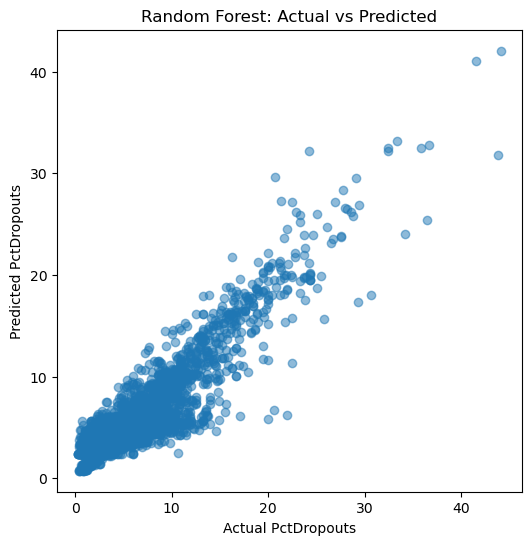

In [168]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual PctDropouts")
plt.ylabel("Predicted PctDropouts")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

The scatter plot shows a strong positive relationship between actual and predicted dropout rates, with most points clustered near the diagonal, indicating that the Random Forest model captures the overall trend effectively. Prediction accuracy is highest for lower and mid-range dropout values, where data is more dense.

However, as dropout rates increase, the spread of points becomes wider, indicating higher variance and reduced accuracy for extreme values. The model also exhibits a regression-to-the-mean effect, where high dropout rates are slightly underestimated and low rates are slightly overestimated.

Overall, the model performs well for the majority of subgroups but struggles with less frequent, high-risk cases, reflecting the impact of data distribution on predictive performance.

### FEATURE IMPORTANCE (Random Forest)

In [169]:
rf_model.fit(X_train, y_train)

# Get feature names after one-hot encoding
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(15)

print(feat_imp)

                                               Feature  Importance
253                                   num__School Year    0.095830
119                cat__SpecialDemo_Active EL Students    0.092909
105                          cat__Race_Hispanic/Latino    0.071299
65         cat__Organization_Kent County Secondary ILC    0.070954
116                               cat__Grade_9th Grade    0.032195
53                   cat__Organization_Douglass School    0.029353
123                          cat__SpecialDemo_Homeless    0.028980
117                            cat__Grade_All Students    0.027337
98         cat__Organization_The Wallace Wallin School    0.025014
93                 cat__Organization_State of Delaware    0.023068
248  cat__District_Geography_State of Delaware_All ...    0.022563
26                     cat__District_State of Delaware    0.021671
24               cat__District_Seaford School District    0.020581
246  cat__District_Geography_Seaford School Distric...    0.01

The feature importance results indicate that both temporal and demographic factors play a significant role in predicting dropout rates. The most important feature is School Year, suggesting that dropout behavior varies over time and may reflect broader trends or policy changes. Among demographic variables, Active EL (English Learner) status, Hispanic/Latino race, and 9th Grade emerge as highly influential, highlighting that early high school years and specific student subgroups are strongly associated with dropout risk.

Additionally, organizational and district-level features (such as specific schools and districts) contribute meaningfully, indicating that institutional context also impacts dropout rates. Features related to vulnerable populations, such as homelessness and low-income status, further reinforce the importance of socioeconomic factors.

Overall, the results suggest that dropout rates are driven by a combination of time trends, demographic characteristics, and institutional context, supporting the use of models capable of capturing complex interactions between these factors.

### EDA Dataset Stats

In [170]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nMissing values by column:")
print(df.isnull().sum())

print("\nUnique values for selected features:")
for col in ["School Year", "Race", "Gender", "Grade", "SpecialDemo", "Geography", "District"]:
    print(col, ":", df[col].nunique())
    print("Sample values:", df[col].dropna().unique()[:10])
    print()

Number of rows: 19831
Number of columns: 18

Missing values by column:
School Year           0
District Code         0
District              0
School Code           0
Organization          0
Race                  0
Gender                0
Grade                 0
SpecialDemo           0
Geography             0
SubGroup              0
RowStatus             0
Dropouts              0
Students              0
PctDropouts           0
Race_Gender           0
Grade_SpecialDemo     0
District_Geography    0
dtype: int64

Unique values for selected features:
School Year : 9
Sample values: [2019 2023 2021 2022 2020 2015 2016 2017 2018]

Race : 8
Sample values: ['Hispanic/Latino' 'African American' 'White' 'Multi-Racial'
 'All Students' 'Native American' 'Asian American'
 'Native Hawaiian/Pacific Islander']

Gender : 3
Sample values: ['All Students' 'Female' 'Male']

Grade : 6
Sample values: ['9th Grade' '10th Grade' '11th Grade' '12th Grade' 'All Students'
 'Twelfth']

SpecialDemo : 13
Sample valu

### EDA: TARGET DISTRIBUTION

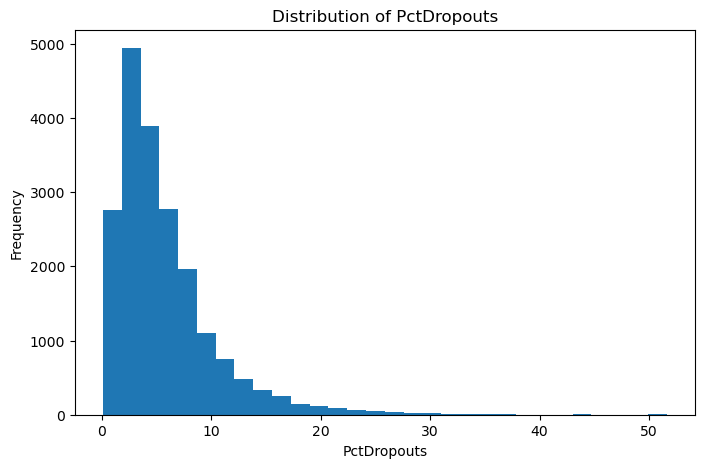

count    19831.000000
mean         5.709137
std          4.651741
min          0.100000
25%          2.600000
50%          4.400000
75%          7.300000
max         51.600000
Name: PctDropouts, dtype: float64


In [171]:
plt.figure(figsize=(8, 5))
plt.hist(df["PctDropouts"], bins=30)
plt.title("Distribution of PctDropouts")
plt.xlabel("PctDropouts")
plt.ylabel("Frequency")
plt.show()

print(df["PctDropouts"].describe())

The distribution of dropout rates is highly right-skewed, with the majority of subgroups concentrated at lower dropout percentages and a long tail extending toward higher values. The median (4.4%) is lower than the mean (5.71%), confirming the presence of positive skew and indicating that a small number of subgroups experience disproportionately high dropout rates.

The interquartile range (2.6% to 7.3%) shows that most observations fall within a relatively narrow band, while the maximum value of 51.6% highlights the presence of extreme outliers. This skewed distribution suggests that dropout risk is unevenly distributed across subgroups, with most students experiencing low risk and a minority facing significantly higher risk.

From a modeling perspective, this imbalance helps explain why models perform well on average but struggle with extreme cases, as high-dropout subgroups are less frequent and harder to learn accurately.

### EDA: AVERAGE DROPOUT RATE BY GRADE

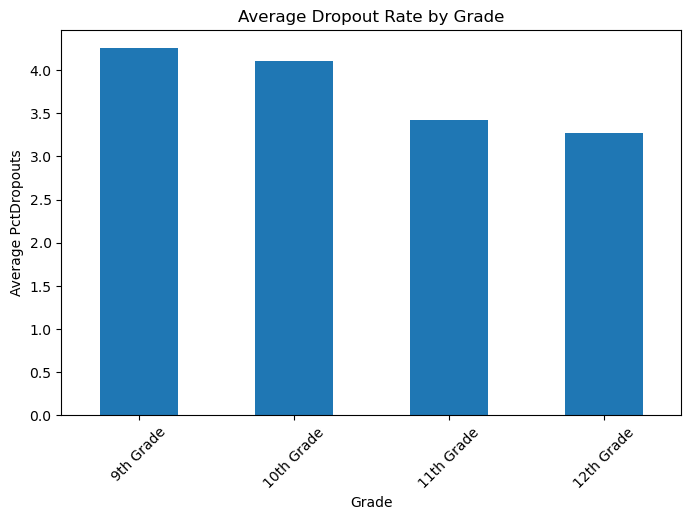

In [172]:
grade_df = df[
    (df["Grade"] != "All Students") &
    (df["Race"] == "All Students") &
    (df["Gender"] == "All Students") &
    (df["SpecialDemo"] == "All Students") &
    (df["Geography"] == "All Students")
].copy()

grade_avg = grade_df.groupby("Grade")["PctDropouts"].mean()

grade_order = ["9th Grade", "10th Grade", "11th Grade", "12th Grade"]
grade_avg = grade_avg.reindex(grade_order)

plt.figure(figsize=(8, 5))
grade_avg.plot(kind="bar")
plt.title("Average Dropout Rate by Grade")
plt.xlabel("Grade")
plt.ylabel("Average PctDropouts")
plt.xticks(rotation=45)
plt.show()

The average dropout rate by grade shows a clear decreasing trend from 9th through 12th grade, with 9th grade exhibiting the highest dropout rate and 12th grade the lowest. This pattern suggests that students are most at risk of dropping out during the early stages of high school, particularly during the transition into 9th grade.

The relatively higher rates in 9th and 10th grade may reflect adjustment challenges, academic difficulty, or disengagement during this critical period. As students progress to later grades, dropout rates decline, likely due to increased persistence among those who remain enrolled.

From a modeling perspective, this trend indicates that grade level is a strong predictive feature, and that dropout risk is not uniformly distributed across time. This reinforces the importance of capturing temporal progression in the model and highlights early high school years as a key target for intervention strategies.

### EDA: AVERAGE DROPOUT RATE BY RACE

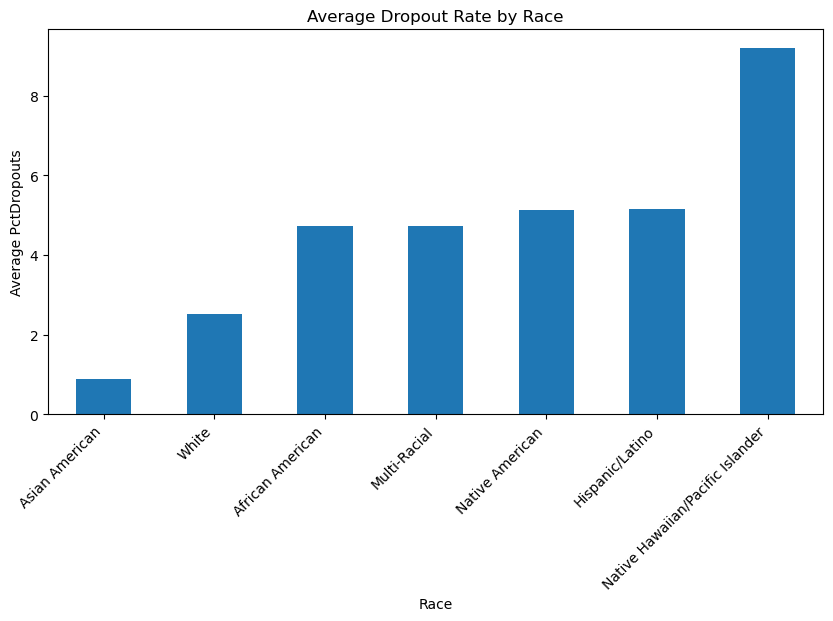

In [173]:
race_df = df[
    (df["Race"] != "All Students") &
    (df["Gender"] == "All Students") &
    (df["Grade"] == "All Students") &
    (df["SpecialDemo"] == "All Students") &
    (df["Geography"] == "All Students")
].copy()

race_avg = race_df.groupby("Race")["PctDropouts"].mean().sort_values()

plt.figure(figsize=(10, 5))
race_avg.plot(kind="bar")
plt.title("Average Dropout Rate by Race")
plt.xlabel("Race")
plt.ylabel("Average PctDropouts")
plt.xticks(rotation=45, ha="right")
plt.show()

The average dropout rate by race reveals notable variation across demographic groups, indicating that dropout risk is not evenly distributed. Certain groups, such as Native Hawaiian/Pacific Islander and Hispanic/Latino students, exhibit higher average dropout rates, while others, such as Asian American students, show significantly lower rates.

These differences suggest that demographic characteristics are strongly associated with dropout outcomes. However, these relationships should be interpreted as correlational rather than causal, as they likely reflect underlying socioeconomic, institutional, or environmental factors not directly captured in the dataset.

From a modeling perspective, the variation across racial groups highlights the importance of including race as a predictive feature, as it contributes meaningful signal to the model. The use of percentage-based dropout rates ensures that these comparisons are standardized across groups of different sizes, allowing for fair and meaningful interpretation.

Overall, the results emphasize that dropout behavior is influenced by a combination of demographic and contextual factors, and that certain student populations may face disproportionately higher risk, making them important targets for intervention strategies.

### EDA: AVERAGE DROPOUT RATE BY GENDER

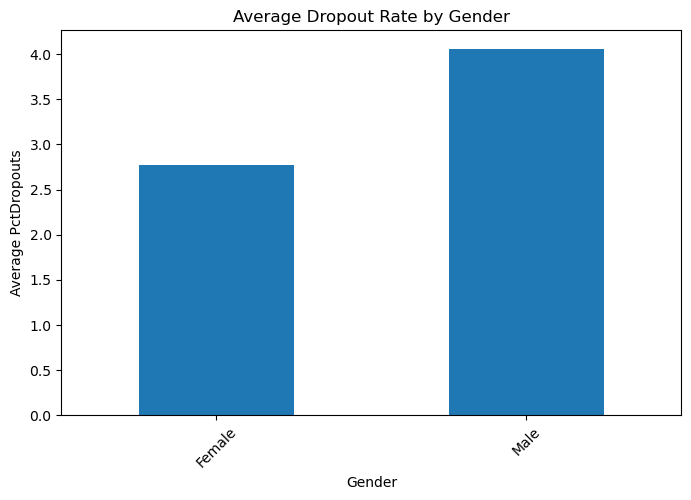

In [174]:
gender_df = df[
    (df["Gender"] != "All Students") &
    (df["Race"] == "All Students") &
    (df["Grade"] == "All Students") &
    (df["SpecialDemo"] == "All Students") &
    (df["Geography"] == "All Students")
].copy()

gender_avg = gender_df.groupby("Gender")["PctDropouts"].mean().sort_values()

plt.figure(figsize=(8, 5))
gender_avg.plot(kind="bar")
plt.title("Average Dropout Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Average PctDropouts")
plt.xticks(rotation=45)
plt.show()

The average dropout rate by gender shows a noticeable difference, with male students exhibiting a higher dropout rate than female students. This suggests that gender is associated with variation in dropout risk, although the magnitude of the difference is moderate compared to other features such as race or grade level.

This pattern may reflect differences in academic engagement, behavioral factors, or external influences that impact student persistence. However, as with other demographic variables, this relationship should be interpreted as correlational rather than causal.

From a modeling perspective, gender contributes useful predictive information, but it is likely most impactful when considered in combination with other features. This reinforces the idea that dropout behavior is influenced by multiple interacting factors rather than a single dominant variable.

### Classification Task

In [175]:
# Secondary goal: classify subgroups as high-risk vs low-risk
# High-risk is defined here as PctDropouts >= 5
df_class = df.copy()

# Same feature engineering used in regression
df_class["Race_Gender"] = df_class["Race"].astype(str) + "_" + df_class["Gender"].astype(str)
df_class["Grade_SpecialDemo"] = df_class["Grade"].astype(str) + "_" + df_class["SpecialDemo"].astype(str)
df_class["District_Geography"] = df_class["District"].astype(str) + "_" + df_class["Geography"].astype(str)

# Create binary target
df_class["HighRisk"] = (df_class["PctDropouts"] >= 5).astype(int)

# Drop leakage / unnecessary columns
df_class_model = df_class.drop(columns=[
    "Dropouts",
    "Students",
    "District Code",
    "School Code",
    "SubGroup",
    "RowStatus",
    "PctDropouts"
], errors="ignore").copy()

X_class = df_class_model.drop(columns=["HighRisk"])
y_class = df_class_model["HighRisk"]

categorical_cols_class = X_class.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols_class = X_class.select_dtypes(include=["int64", "float64"]).columns.tolist()

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

preprocessor_class = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_class),
    ("num", StandardScaler(), numerical_cols_class)
])

### Classification Models 

In [176]:
# Logistic Regression and Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

clf_log = Pipeline([
    ("preprocessor", preprocessor_class),
    ("model", LogisticRegression(max_iter=500))
])

clf_tree = Pipeline([
    ("preprocessor", preprocessor_class),
    ("model", DecisionTreeClassifier(max_depth=10, random_state=42))
])

clf_log.fit(X_train_c, y_train_c)
clf_tree.fit(X_train_c, y_train_c)

y_pred_log = clf_log.predict(X_test_c)
y_pred_tree = clf_tree.predict(X_test_c)

### Classification Metrics 

In [177]:
classification_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree Classifier"],
    "Accuracy": [
        accuracy_score(y_test_c, y_pred_log),
        accuracy_score(y_test_c, y_pred_tree)
    ],
    "Precision": [
        precision_score(y_test_c, y_pred_log),
        precision_score(y_test_c, y_pred_tree)
    ],
    "Recall": [
        recall_score(y_test_c, y_pred_log),
        recall_score(y_test_c, y_pred_tree)
    ],
    "F1 Score": [
        f1_score(y_test_c, y_pred_log),
        f1_score(y_test_c, y_pred_tree)
    ]
})

print(classification_results)

                      Model  Accuracy  Precision    Recall  F1 Score
0       Logistic Regression  0.816990   0.802339  0.795254  0.798780
1  Decision Tree Classifier  0.814469   0.751873  0.886313  0.813576


The classification results show that both Logistic Regression and the Decision Tree Classifier achieve similar overall accuracy (approximately 81–82%), indicating that both models are effective at distinguishing between high-risk and low-risk subgroups. However, differences emerge when examining precision and recall, highlighting trade-offs in model behavior.

Logistic Regression demonstrates higher precision (0.80), meaning it is more conservative and produces fewer false positives when identifying high-risk groups. In contrast, the Decision Tree Classifier achieves significantly higher recall (0.89), indicating that it is better at identifying a larger proportion of true high-risk subgroups, but at the cost of lower precision (0.75), resulting in more false positives.

The F1 scores for both models are similar, suggesting a balanced overall performance. From an application perspective, the higher recall of the Decision Tree may be more desirable in this context, as failing to identify at-risk students (false negatives) can be more costly than incorrectly flagging some low-risk groups. Overall, the results highlight the trade-off between precision and recall and demonstrate that model selection should be guided by the specific priorities of the intervention strategy.